## Example - Solving a first order differential equation using a PQK


This notebook demonstrates how to use sQUlearns's quantum kernels implementation to solve differential equations

### Imports

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt


from squlearn import Executor
from squlearn.encoding_circuit import ChebyshevTower, LayeredEncodingCircuit
from squlearn.kernel.matrix import ProjectedQuantumKernel, KernelOptimizer
from squlearn.kernel.loss.ODE_loss import ODELoss
from squlearn.kernel.ml import QKODE
from squlearn.optimizers import LBFGSB, Adam


We will use the Pennylane quantum framework for executing the circuits.

In [2]:
executor = Executor("pennylane", shots=None)

## `QNNRegressor` Setup

We start by defining the parameterized quantum circuit (PQC), that calculates the quantum kernel $k^{\text{PQK}}(x,y)$

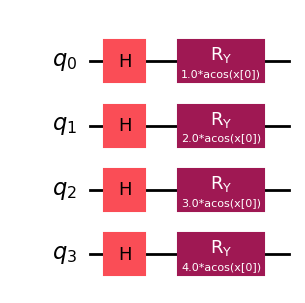

In [3]:
circuit = ChebyshevTower(num_qubits=4, num_features=1, num_chebyshev=4, num_layers=1)
circuit.draw("mpl")

Now, we can easily create the Projected Quantum Kernel object that will be used to compute the kernel matrix.

In [4]:
pqk = ProjectedQuantumKernel(executor=executor, encoding_circuit=circuit)

We proceed to define the ODE to be solved, 

\begin{equation}
\frac{df(x)}{dx} - \lambda e^{-\lambda x k} \sin(\lambda x) - \lambda k f(x) = 0
\end{equation}


We create the homogeneous differential equation to be used using a sympy symbolic expression


In [5]:
x, f, dfdx = sp.symbols("x f dfdx")
lamb, k = 10, 0.4
eq = dfdx - (-lamb * sp.exp(-lamb * x * k) * sp.sin(lamb * x) - lamb * k * f)
initial_values = [1]
eq

dfdx + 4.0*f + 10*exp(-4.0*x)*sin(10*x)

Now we need to create an instance of `ODELoss`, the symbols involved in the ODE must be provided in the correct order: independent variable, function, and higher orders

In [6]:
loss_ODE_squ = ODELoss(
    eq,
    symbols_involved_in_ODE=[x, f, dfdx],
    initial_values=initial_values,
    boundary_handling="pinned",
    eta=0.02
)

An instance of `KernelOptimizer` is created. The instance takes the kernel of choice, the loss function, the optimizer and initial ansatz parameter

In [7]:
x_train = np.linspace(0, 0.9, 35).reshape(-1, 1)
x_test = np.random.rand(30, 1) * 0.9
x_test = np.sort(x_test, axis=0)

labels = np.zeros((len(x_train), 1))
parameter_values = np.random.rand(len(x_train)+1)
optimizer=LBFGSB()


model = QKODE(pqk, loss_ODE_squ, 0.1, optimizer)
model.fit(x_train, labels)

QKODE(alpha=0.1,
      quantum_kernel=<squlearn.kernel.matrix.projected_quantum_kernel.ProjectedQuantumKernel object at 0x0000012EF5A65FC0>)

### Evaluation

Let's print the optimal parameters of the QK ansatz and operator

In [8]:
model.dual_coeff_

array([ 0.07283771,  2.07789121, -0.16008901, -0.35144539, -0.98730764,
       -0.102882  ,  0.15708279,  0.3453661 ,  0.18549903,  0.00888856,
       -0.03569696, -0.87062085,  0.11576312, -0.08850544,  0.37798495,
        0.10126435, -0.22208988,  0.2785577 , -0.52390493, -0.07997036,
        0.15162522,  0.54024789, -0.1193779 , -0.26771426, -0.33243051,
        0.40478274,  0.15896445, -0.15293917,  0.05366851, -0.33585714,
        0.11982443,  0.43007366, -0.38401349, -0.28174442,  0.5322575 ,
       -0.31838041])

Text(0, 0.5, 'f')

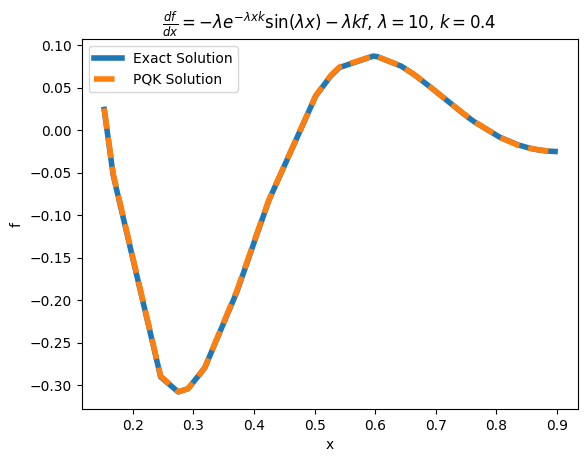

In [9]:
plt.plot(x_test, np.exp(-10 * x_test * 0.4) * np.cos(10 * x_test), label = "Exact Solution", linewidth=4)
plt.plot(x_test, model.predict(x_test), label = "PQK Solution", linewidth=4, linestyle="--")
plt.legend()
plt.title(r"$\frac{df}{dx} = -\lambda e^{-\lambda x k} \sin(\lambda x) - \lambda k f$, $\lambda = 10$, $k = 0.4$")
plt.xlabel("x")
plt.ylabel("f")